# Section 8.3.2：Principal component regression
### The dry matter of mangoes was predicted using near-infrared (NIR) spectral data

In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [03:30<00:00,  1.05s/it]


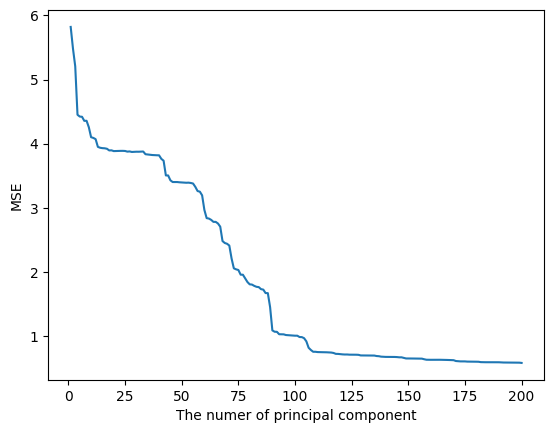

In [2]:
# Load  NIR spectral data
NIR_data = pd.read_csv('./jupyter_data/MangoNIRData_train.csv')

# Near-infrared spectral data extracted from the CSV file were taken as predictors (X) 
# and the dry matter content as the response variable (Y)."
X = NIR_data.iloc[:, 9:].values
Y = NIR_data.iloc[:, 8].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Employ K-fold cross-validation to acquire the optimal number of principal components.
kf = KFold(n_splits=10, shuffle=True, random_state=1) # 10-fold cross-validation
mse_kf = []
max_pc = 200
for i in tqdm(np.arange(1, max_pc+1)):
    # Build PCR pipeline with varying numbers of principal components
    pcr_model = Pipeline([
        ('pca', PCA(n_components=i)), # Apply PCA
        ('regressor', LinearRegression())]) # Linear regression on PCs
    score = cross_val_score(pcr_model, X_train, Y_train, cv=kf, scoring='neg_mean_squared_error').mean() # Obtain the performance metric [-mse] of the PLSR model
    mse_kf.append(-score)

fig, ax = plt.subplots()
ax.plot(np.arange(1, max_pc+1), mse_kf)
ax.set_xlabel('The numer of principal component')
ax.set_ylabel('MSE')
plt.show()

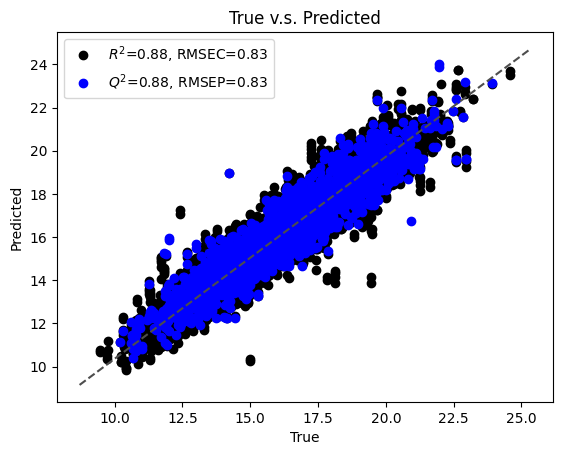

In [3]:
# According to the MSE distribution across principal components, 
# 125 could be selected as the optimal number of principal components to balance model performance and computational cost.

optimal_pc = 125

# PCR model with the optimal number of principal components
pcr_model2 = Pipeline([
        ('pca', PCA(n_components=optimal_pc)),
        ('regressor', LinearRegression())])
pcr_model2.fit(X_train, Y_train)

# The performance of the PCR model was assessed by calculating the Root Mean Square Error (RMSE) and the coefficient of determination (R²).
def rmse(y, yp):
    return np.sqrt(mean_squared_error(y, yp))

yp_train = pcr_model2.predict(X_train)
yp_test = pcr_model2.predict(X_test)

R2 = r2_score(Y_train, yp_train)
Q2 = r2_score(Y_test, yp_test)
rmsec = rmse(Y_train, yp_train)
rmsep = rmse(Y_test, yp_test)

# Scatter plot of true vs. predicted values
plt.figure()
plt.plot(Y_train, yp_train, 'ko', label=f"$R^2$={R2:.2f}, RMSEC={rmsec:.2f}")  # Training set: black circles
plt.plot(Y_test, yp_test, 'bo', label=f"$Q^2$={Q2:.2f}, RMSEP={rmsep:.2f}")  # Validation set: blue circles
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True v.s. Predicted')
plt.legend()
ax = plt.gca()
ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")

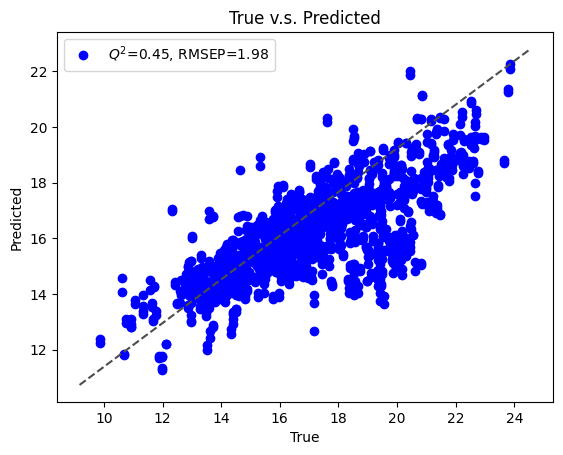

In [4]:
# Predict the dry matter content in the external test set using the model.
NIR_data_test = pd.read_csv('./jupyter_data/MangoNIRData_test.csv')
X_t = NIR_data_test.iloc[:, 9:].values
X_t_scaled = scaler.fit_transform(X_t)

yp_t = pcr_model2.predict(X_t_scaled)

# Assess the prediction performance of model
y_t = NIR_data_test.iloc[:, 8].values

Q2 = r2_score(y_t, yp_t)
rmsep = rmse(y_t, yp_t)

# Scatter plot of true vs. predicted values
plt.figure()
plt.plot(y_t, yp_t, 'bo', label=f"$Q^2$={Q2:.2f}, RMSEP={rmsep:.2f}")  # External test set: blue circles
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True v.s. Predicted')
plt.legend()
ax = plt.gca()
ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")


# Section 8.3.3：Partial least squares regression
### The dry matter of mangoes was predicted using near-infrared (NIR) spectral data

In [6]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from tqdm import tqdm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:34<00:00,  4.29s/it]


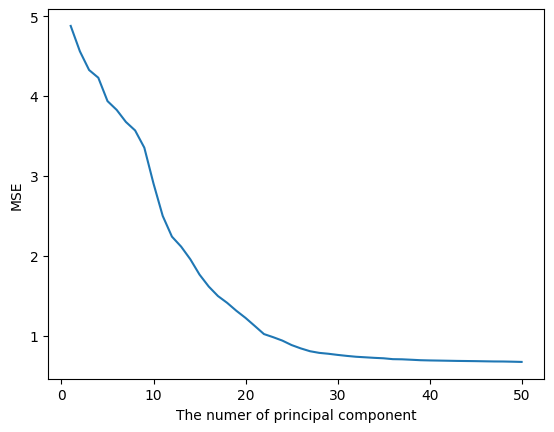

In [8]:
# Load  NIR spectral data
NIR_data = pd.read_csv('./jupyter_data/MangoNIRData_train.csv')

# Near-infrared spectral data extracted from the CSV file were taken as predictors (X) 
# and the dry matter content as the response variable (Y)."
X = NIR_data.iloc[:, 9:].values
Y = NIR_data.iloc[:, 8].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

# Employ K-fold cross-validation to acquire the optimal number of principal components.
kf = KFold(n_splits=10, shuffle=True, random_state=1) # 10-fold cross-validation
mse_kf = []
max_pc = 50
for i in tqdm(np.arange(1, max_pc+1)):
    pls = PLSRegression(n_components=i)
    score = cross_val_score(pls, X_train, Y_train, cv=kf, scoring='neg_mean_squared_error').mean()
    mse_kf.append(-score)

fig, ax = plt.subplots()
ax.plot(np.arange(1, max_pc+1), mse_kf)
ax.set_xlabel('The numer of principal component')
ax.set_ylabel('MSE')
plt.show()

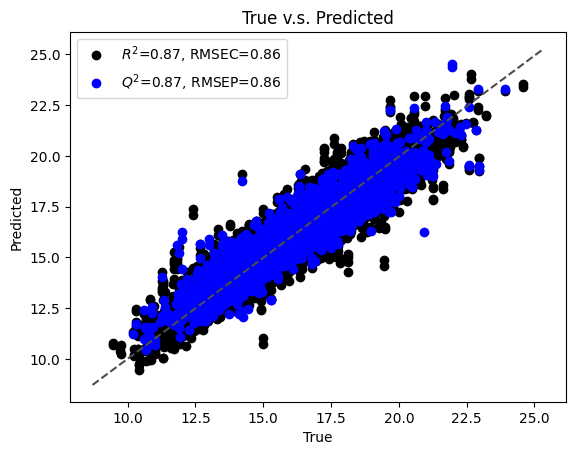

In [9]:
# According to the MSE distribution across principal components, 
# 30 could be selected as the optimal number of principal components to balance model performance and computational cost.

optimal_pc = 30

# PLS model with the optimal number of principal components
pls2 = PLSRegression(n_components=optimal_pc)
pls2.fit(X_train, Y_train)

# The performance of the PCR model was assessed by calculating the Root Mean Square Error (RMSE) and the coefficient of determination (R²).
def rmse(y, yp):
    return np.sqrt(mean_squared_error(y, yp))

yp_train = pls2.predict(X_train)
yp_test = pls2.predict(X_test)

R2 = r2_score(Y_train, yp_train)
Q2 = r2_score(Y_test, yp_test)
rmsec = rmse(Y_train, yp_train)
rmsep = rmse(Y_test, yp_test)

# Scatter plot of true vs. predicted values
plt.figure()
plt.plot(Y_train, yp_train, 'ko', label=f"$R^2$={R2:.2f}, RMSEC={rmsec:.2f}")  # Training set: black circles
plt.plot(Y_test, yp_test, 'bo', label=f"$Q^2$={Q2:.2f}, RMSEP={rmsep:.2f}")  # Validation set: blue circles
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True v.s. Predicted')
plt.legend()
ax = plt.gca()
ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")

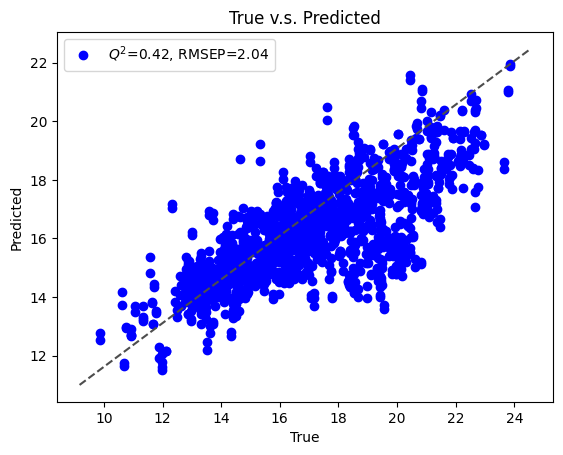

In [10]:
# Predict the dry matter content in the external test set using the model.
NIR_data_test = pd.read_csv('./jupyter_data/MangoNIRData_test.csv')
X_t = NIR_data_test.iloc[:, 9:].values
X_t_scaled = scaler.fit_transform(X_t)

yp_t = pls2.predict(X_t_scaled)

# Assess the prediction performance of model
y_t = NIR_data_test.iloc[:, 8].values

Q2 = r2_score(y_t, yp_t)
rmsep = rmse(y_t, yp_t)

# Scatter plot of true vs. predicted values
plt.figure()
plt.plot(y_t, yp_t, 'bo', label=f"$Q^2$={Q2:.2f}, RMSEP={rmsep:.2f}")  # External test set: blue circles
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True v.s. Predicted')
plt.legend()
ax = plt.gca()
ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")

# Section 8.4.2：Iterative target transformation factor analysis (ITTFA) 
### Resolving overlapping two-component GC-MS signals via ITTFA

In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
import matplotlib.ticker as ticker
from sklearn.metrics import explained_variance_score
import tensorly as tl
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve

In [12]:
def back_remove(xx):
    '''
    * Function：Background removing
    *
    * Input
    * ----------
    * xx：GC-MS data with array format
    *
    * Output
    * ---------
    * bak：GC-MS data afer background removing
    '''
    Ns = [[0,3],[xx.shape[0]-3,xx.shape[0]]]

    bak = np.zeros(xx.shape)
    for i in range(0, xx.shape[1]):
        tiab = []
        reg = []
        for j in range(0, len(Ns)):
            tt = range(Ns[j][0],Ns[j][1])
            tiab.extend(xx[tt, i])
            reg.extend(np.arange(Ns[j][0], Ns[j][1]))
        rm = reg - np.mean(reg)
        tm = tiab - np.mean(tiab)
        b = np.dot(np.dot(float(1)/np.dot(rm.T, rm), rm.T), tm)
        s = np.mean(tiab)-np.dot(np.mean(reg), b)
        b_est = s+b*np.arange(xx.shape[0])
        bak[:, i] = xx[:, i]-b_est
    return bak

def WhittakerSmooth(x,w,lambda_,differences=1):
    """
    * Function: Whittaker smoothing algorithm for baseline estimation.
    *
    * Input
    * ----------
    * x: Input one-dimensional signal (e.g., spectrum or chromatogram).
    * w: Weight vector, used to penalize certain regions in the signal.
    * lambda_: Smoothing parameter, Larger values result in a smoother baseline.
    * differences: Order of differences, which determine the stiffness of the smoothing.
    *
    * Output
    * ----------
    * background: The estimated smooth background or baseline.
    """
    X = np.matrix(x)
    m = X.size
    E = eye(m, format='csc')
    for i in range(differences):
        E = E[1:] - E[:-1]
    W = diags(w, 0, shape=(m,m))
    A = csc_matrix(W + (lambda_*E.T*E))
    B = csc_matrix(W*X.T)
    background = spsolve(A,B)
    return np.array(background)

def airPLS(x, lambda_=500, porder=1, itermax=15):
    """
    * Function: Adaptive Iteratively Reweighted Penalized Least Squares (airPLS) algorithm for baseline correction.
    *
    * Input
    * ----------
    * x: Input one-dimensional signal (e.g., spectrum or chromatogram).
    * lambda_: Smoothing parameter, Larger values result in a smoother baseline.
    * Porder: The order of the difference matrix used in smoothing.
    * itermax: Maximum number of iterations.
    *
    * Output
    * ----------
    * baseline: Estimated baseline to be subtracted from the original signal.
    """
    m = x.shape[0]
    w = np.ones(m)
    for i in range(1, itermax+1):
        z = WhittakerSmooth(x, w, lambda_, porder)
        d = x-z
        dssn = np.abs(d[d<0].sum())
        if(dssn < 0.001*(abs(x)).sum() or i == itermax):
            break
        if np.any(d < 0):
            w[d >= 0] = 0
            w[d < 0] = np.exp(i * np.abs(d[d < 0]) / dssn)
            w[0] = np.exp(i * (d[d < 0]).max() / dssn)
            w[-1] = w[0]
        else:
            break

    return z

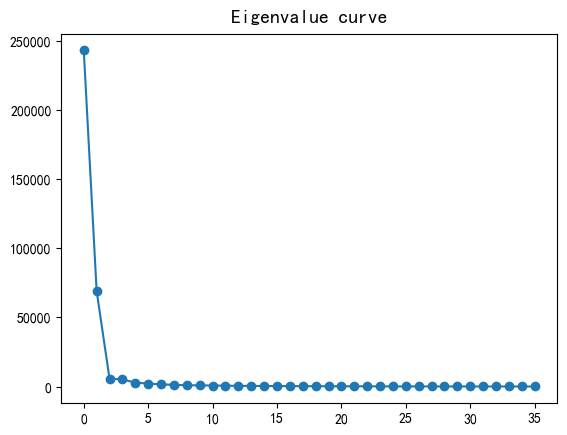

In [13]:
# Load GC-MS data
file_path = ('./jupyter_data/two-component.npy')
X0 = np.load(file_path)

# Raw data preprocessing
# Background removing
X = back_remove(X0)
X[X < 0] = 0

# Baseline correction
for i in range(X.shape[1]):
    X[:, i] = X[:, i] - airPLS(X[:, i])
X[X < 0] = 0

# Determine the number of components using singular value decomposition (SVD)
u, s0, v = np.linalg.svd(X)

# Determining the number of components using the S0 vector
fig, ax = plt.subplots()
ax.plot(s0)
ax.scatter(np.arange(0,len(s0)),s0)
ax.set_title('Eigenvalue curve', fontsize=14, pad=8)
plt.show()

**The eigenvalue curve reveals two eigenvalues that are markedly greater than zero, suggesting that the overlapping peak comprises two components**

In [14]:
COM = 2

**ITTFA method**

In [15]:
def unimod(c, rmod, cmod, imax=None):
    """
    * Function: Enforce unimodality constraint on chromatographic profiles.
    *
    * Input
    * ----------
    * c: 2D array of chromatographic profiles (shape: n_samples × n_components).
    * rmod: Relaxation factor, allows minor deviations from strict monotonicity. Used to define a tolerance threshold for peak shape.
    * cmod: Correction mode:
    *        0 - set offending points to zero,
    *        1 - set to neighbor value (smoothing),
    *        2 - average with neighbor (stronger smoothing).
    * imax: Indices of peak maxima for each component.
    *
    * Output
    * ----------
    * c: Modified matrix with unimodality enforced on each column.
    """
    ns = c.shape[1]
    if imax is None:
        imax = np.argmax(c, axis=0)
    for j in range(0, ns):
        rmax = c[imax[j], j]
        k = imax[j]
        while k > 0:
            k = k-1
            if c[k, j] <= rmax:
                rmax = c[k, j]
            else:
                rmax2 = rmax*rmod
                if c[k, j] > rmax2:
                    if cmod == 0:
                        c[k, j] = 0  # 1e-30
                    if cmod == 1:
                        c[k, j] = c[k+1, j]
                    if cmod == 2:
                        if rmax > 0:
                            c[k, j] = (c[k, j]+c[k+1, j])/2
                            c[k+1, j] = c[k, j]
                            k = k+2
                        else:
                            c[k, j] = 0
                    rmax = c[k, j]
        rmax = c[imax[j], j]
        k = imax[j]

        while k < c.shape[0]-1:
            k = k+1
            if k == 53:
                k = 53
            if c[k, j] <= rmax:
                rmax = c[k, j]
            else:
                rmax2 = rmax*rmod
                if c[k, j] > rmax2:
                    if cmod == 0:
                        c[k, j] = 1e-30
                    if cmod == 1:
                        c[k, j] = c[k-1, j]
                    if cmod == 2:
                        if rmax > 0:
                            c[k, j] = (c[k, j]+c[k-1, j])/2
                            c[k-1, j] = c[k, j]
                            k = k-2
                        else:
                            c[k, j] = 0
                    rmax = c[k, j]
    return c

def fnnls(x, y, tole):
    """
    * Function: Solve the non-negative least squares (NNLS) problem using the Fast NNLS algorithm.
    *
    * Input
    * ----------
    * x: Design matrix (features), shape (n_features, n_samples)
    * y: Observation vector (response), shape (n_samples,)
    * tole: Tolerance for convergence. If 'None', automatically calculated based on machine precision.
    *
    * Output
    * ----------
    * dict:{'xx': The estimated solution vector that satisfies the non-negativity constraint
            'w': The dual vector (gradient of the objective function at the solution)}
    """
    xtx = np.dot(x, x.T)
    xty = np.dot(x, y.T)
    if tole == 'None':
        tol = 10*np.spacing(1)*np.linalg.norm(xtx)*max(xtx.shape)
    mn = xtx.shape
    P = np.zeros(mn[1])
    Z = np.array(range(1, mn[1]+1), dtype='int64')
    xx = np.zeros(mn[1])
    ZZ = Z-1
    w = xty-np.dot(xtx, xx)
    iter = 0
    itmax = 30*mn[1]
    z = np.zeros(mn[1])
    while np.any(Z) and np.any(w[ZZ] > tol):
        t = ZZ[np.argmax(w[ZZ])]
        P[t] = t+1
        Z[t] = 0
        PP = np.nonzero(P)[0]
        ZZ = np.nonzero(Z)[0]
        nzz = np.shape(ZZ)
        if len(PP) == 1:
            z[PP] = xty[PP]/xtx[PP, PP]
        elif len(PP) > 1:
            if np.linalg.det(xtx[np.ix_(PP, PP)]) == 0:
                small = 1e-6*np.identity(xtx[np.ix_(PP, PP)].shape[0])
                z[PP] = np.dot(xty[PP], np.linalg.inv(xtx[np.ix_(PP, PP)]+small))
            else:
                z[PP] = np.dot(xty[PP], np.linalg.inv(xtx[np.ix_(PP, PP)]))
        z[ZZ] = np.zeros(nzz)
        while np.any(z[PP] <= tol) and iter < itmax:
            iter += 1
            qq = np.nonzero((tuple(z <= tol) and tuple(P != 0)))
            epsilon = 1e-10
            divider = xx[qq] - z[qq]
            divider[abs(divider) < epsilon] = epsilon
            alpha = np.min(xx[qq] / divider)
            xx = xx + alpha*(z - xx)
            ij = np.nonzero(tuple(np.abs(xx) < tol) and tuple(P != 0))
            Z[ij[0]] = ij[0]+1
            P[ij[0]] = np.zeros(max(np.shape(ij[0])))
            PP = np.nonzero(P)[0]
            ZZ = np.nonzero(Z)[0]
            nzz = np.shape(ZZ)
            if len(PP) == 1:
                z[PP] = xty[PP]/xtx[PP, PP]
            elif len(PP) > 1:
                z[PP] = np.dot(xty[PP], np.linalg.inv(xtx[np.ix_(PP, PP)]))
            z[ZZ] = np.zeros(nzz)
        xx = np.copy(z)
        xx[xx < 0] = 0
        w = xty - np.dot(xtx, xx)
    return {'xx': xx, 'w': w}

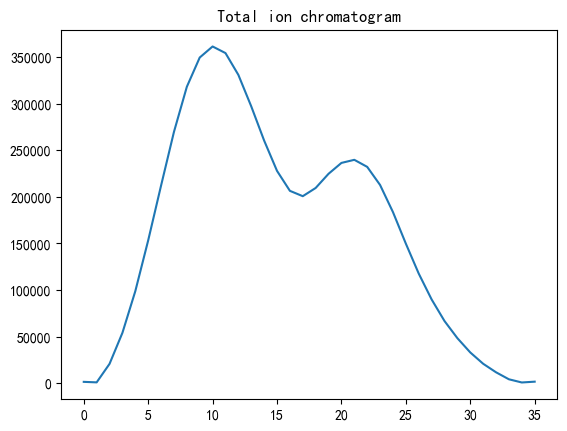

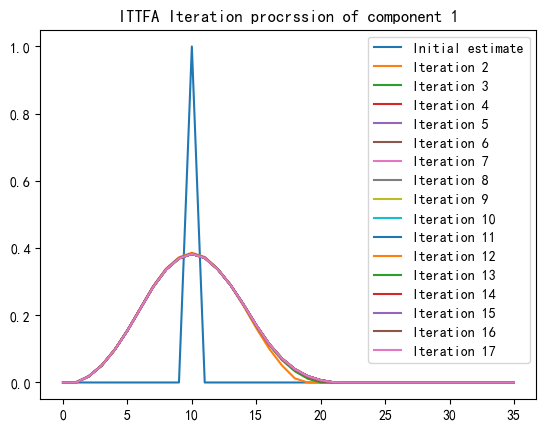

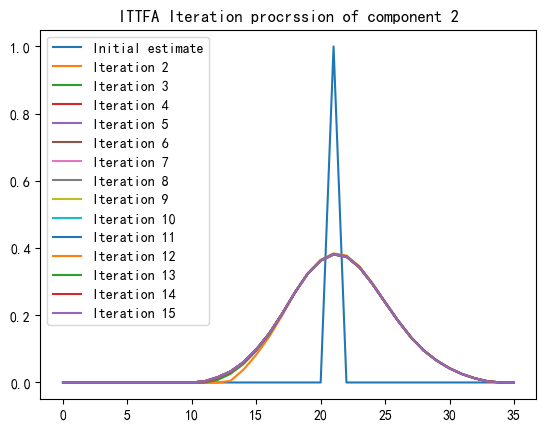

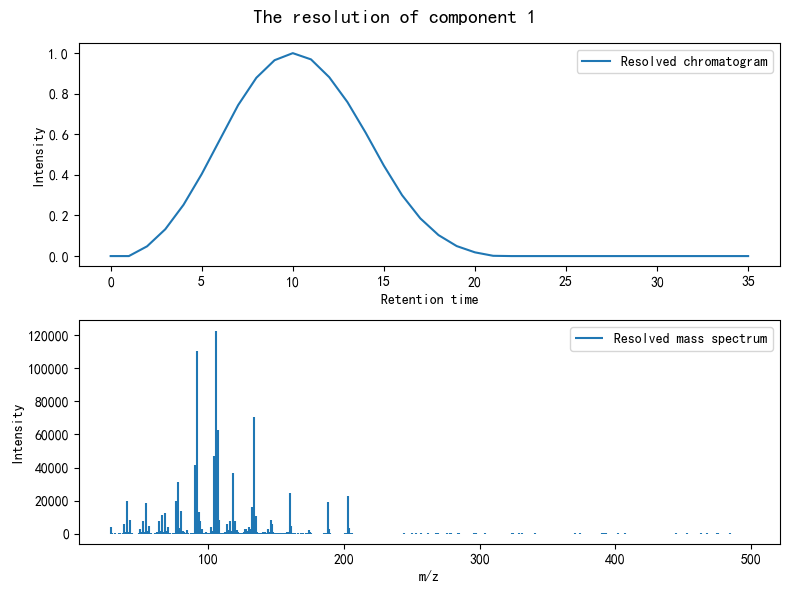

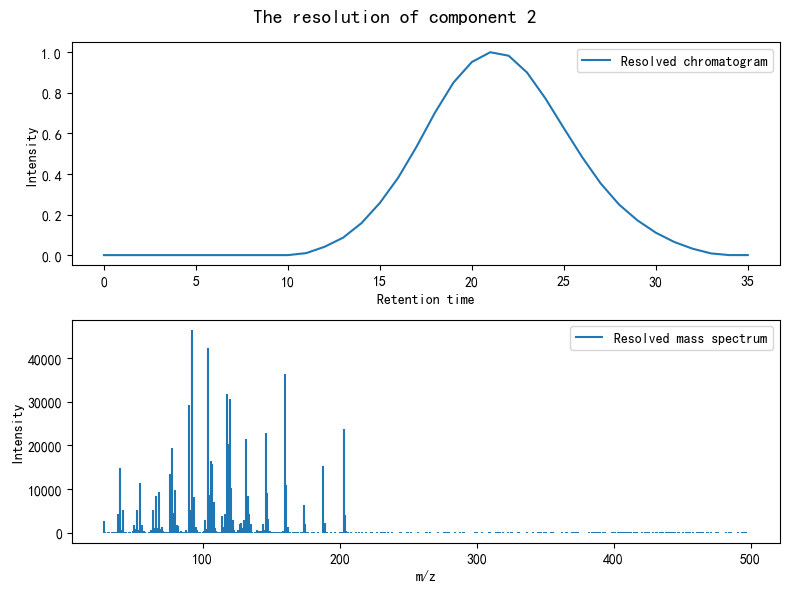

In [16]:
# ITTFA method
u, s, v = tl.truncated_svd(X, COM)
T = np.dot(u, np.diag(s))

# Needle search is utilized to get initial chromatographic estimates 
# The initial chromatographic estimates are determined by analyzing the peak maxima in the total ion chromatogram.
plt.figure()
plt.plot([np.sum(X[i, :]) for i in range(X.shape[0])])
plt.title('Total ion chromatogram')
plt.show()

C_0 = np.zeros((36, 2))
C_0[10, 0] = 1
C_0[21, 1] = 1
C_ed = np.zeros((C_0.shape[0], COM))

max_iter = 30
tolerance = 1e-6
for r in range(COM):
    plt.figure()
    plt.title(f'ITTFA Iteration procrssion of component {r+1}')
    plt.plot(C_0[:, r], label='Initial estimate')

    C = C_0[:, r].reshape((C_0[:, r].shape[0], 1))
    l = 0
    while l < max_iter:
        C_st = C
        C = np.dot(np.dot(np.dot(T, np.linalg.pinv(np.dot(T.T, T))), T.T), C)
        C[C < 0] = 0 # constrains (non-negative)
        C = unimod(C, 1.1, 2)
        if np.linalg.norm(C) != 0:
            C = C/np.linalg.norm(C)
        normc = np.linalg.norm(C-C_st)
        l += 1
        C = C.reshape((C_0.shape[0]))
        C_ed[:, r] = C
        C = C.reshape((C_0.shape[0], 1))

        color = plt.cm.viridis(i / max_iter)
        plt.plot(C, label=f'Iteration {l+1}')
        
        if normc < tolerance or l == max_iter:
            C = C.reshape((C_0.shape[0]))
            C_ed[:, r] = C
            break
    plt.legend()
    plt.show()

# Resolving spectrum based on resolved chromatogram with fnnls algorithm 
St = np.zeros((COM, X.shape[1]))
for j in range(0, St.shape[1]):
    a = fnnls(np.dot(C_ed.T, C_ed), np.dot(C_ed.T, X[:, j]), tole='None')
    St[:, j] = a['xx']

# Plot the resolved chromatogram and mass spectrum for each component
for r in range(COM):
    C = C_ed[:, r] / np.max(C_ed[:, r])
    spectrum = St[r, :] / np.max(St[r, :]) * 999
    mz_min = min(np.where(St[r,:]>0)[0])
    mz_max = max(np.where(St[r,:]>0)[0])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)
    fig.suptitle(f'The resolution of component {r+1}', fontsize=14)
    ax1.plot(C, label='Resolved chromatogram')
    ax1.set_xlabel('Retention time')
    ax1.set_ylabel('Intensity')
    ax1.legend()
    ax2.vlines(np.arange(mz_min, mz_max), ymin=0, ymax=St[r, mz_min:mz_max],
               label='Resolved mass spectrum')
    ax2.set_xlabel('m/z')
    ax2.set_ylabel('Intensity')
    ax2.legend()
    plt.tight_layout()
    plt.show()

**The resolution quality can be assessed by computing the explained variance; a value closer to 1 indicates a better resolution outcome**

Explained variance score is 0.997


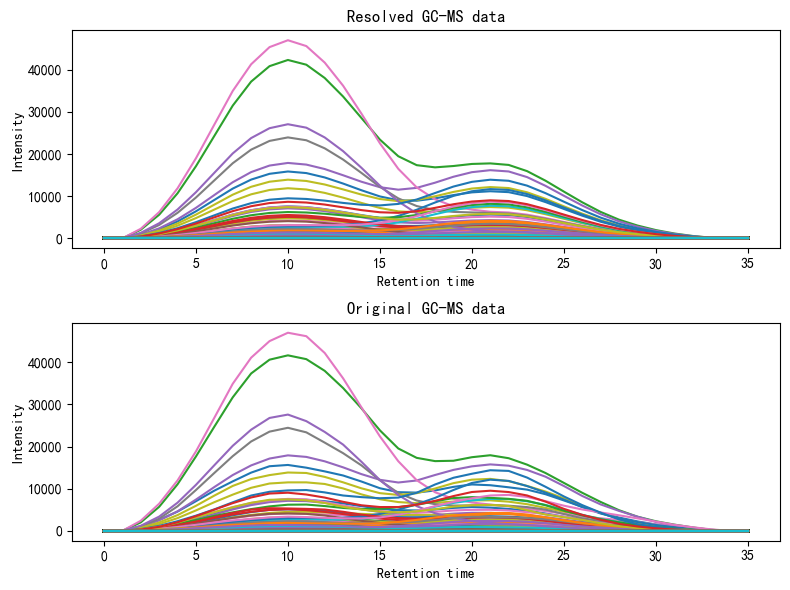

In [17]:
resolved_X = np.dot(C_ed, St)
R2 = round(explained_variance_score(X, resolved_X, multioutput='variance_weighted'), 3)
print(f"Explained variance score is {R2}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=False)
ax1.plot(resolved_X)
ax1.set_xlabel('Retention time')
ax1.set_ylabel('Intensity')
ax1.set_title('Resolved GC-MS data')
ax2.plot(X)
ax2.set_xlabel('Retention time')
ax2.set_ylabel('Intensity')
ax2.set_title('Original GC-MS data')
plt.tight_layout()
plt.show()

# Section 8.4.3：Evolving Factor Analysis (EFA)
### Determine the elution order of components in a two-component overlapping peak using EFA.

In [18]:
import numpy as np

def EFA(X, num):
    '''
    * Function: Determine the inflow and outflow information of compounds through the evolving factor analysis method
    *
    * Input
    * ----------
    * X: Matrix form of GC-MS data
    * num: Number of leading singular values to retain and visualize
    *
    * Output
    * ---------
    * X: The original input matrix
    * eig_forward: Logarithm of the first num eigenvalues from the forward calculation
    * eig_backward: Logarithm of the first num eigenvalues from the backward calculation
    '''
    s_forward = []
    s_backward = []
    for i in range(1, len(X)):
        xx_forward = X[0:i + 1]
        xx_backward = X[-(i + 1):]
        U_F, S_F, VT_F = np.linalg.svd(xx_forward)  # forward calculation
        U_B, S_B, VT_B = np.linalg.svd(xx_backward)  # backward calculation
        s_forward.append(S_F)
        s_backward.append(S_B)
    
    s0_forward = np.zeros((len(X), len(X)))
    for i in range(1, len(s0_forward)):
        s0_forward[i, 0:len(s_forward[i - 1])] = s_forward[i - 1]
    eig_forward = np.log10(s0_forward[:, :num])
    
    s0_backward = np.zeros((len(X), len(X)))
    for i in range(1, len(s0_backward)):
        s0_backward[i - 1, 0:len(s_forward[-i])] = s_backward[-i]
    eig_backward = np.log10(s0_backward[:, :num])
    
    return X, eig_forward, eig_backward

**The same two-component overlapping peak as in Section 8.4.2 is used as the example data. Based on the singular value decomposition in Section 8.4.2, it is determined that the overlapping peak contains two components. In the `EFA()` function, the parameter `num` specifies the number of leading singular values to retain, which is typically set to the estimated number of components or slightly higher, in order to distinguish major components from background noise. Therefore, the first (2 + 4) singular values are selected for plotting, and the second argument passed to `EFA()` is set to 6 accordingly.**

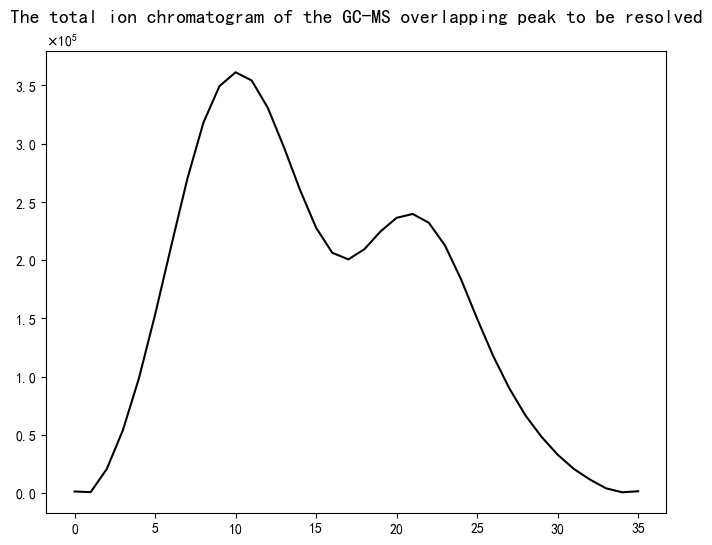

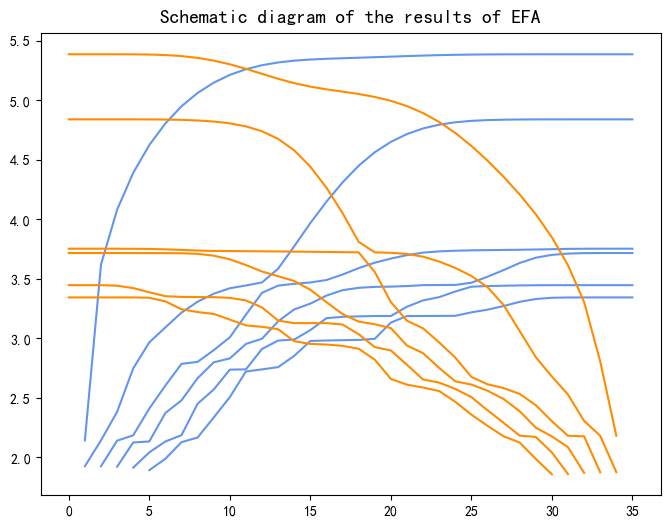

In [19]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

peak, eig_forward, eig_backward = EFA(X, 6)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.sum(X, 1), color = 'black')
ax.set_title('The total ion chromatogram of the GC-MS overlapping peak to be resolved', fontsize=14, pad=8)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(formatter)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Schematic diagram of the results of EFA', fontsize=14, pad=8)
ax.plot(eig_forward, color='cornflowerblue')
ax.plot(eig_backward, color='darkorange')
plt.show()

**From the schematic diagram of the results of EFA, it can be determined that the selective region for the first eluting component spans scan points 2 to 14, the co-elution region spans scan points 15 to 19, and the zero-concentration region spans scan points 20 to 31.**

# Section 8.4.4：Full-rank resolution
### Resolving overlapping two-component GC-MS signals (the same as section 8.4.3) via full-rank resolution

In [20]:
def contrain_FRR(c, s, o):
    '''
    * Function: Optimize the GC-MS peaks to be distinguished (serving the function FRR)
    *
    * Input
    * ----------
    * c: The chromatographic profile of the component to be resolved
    * s: The selective region of the component to be resolved
    * o:The co-elution region of the component and other components to be resolved
    *
    * Output
    * ---------
    * c: Optimized chromatographic profile
    * ind_s: The scanning points of the mass spectrometry to be taken for the components to be resolved
    '''
    ind_s = np.argmax(np.abs(c[s]))
    
    if c[s][ind_s] < 0:
        c = -c
    
    if s[0] < o[0]:
    
        if c[s[-2]] < c[s[-1]]:
            ind1 = s[-1]
            ind2 = o[np.argmax(c[o])]
        else:
            ind1 = s[np.argmax(c[s])]
            ind2 = o[0]
    else:
        if c[s[1]] < c[s[0]]:
            ind1 = o[np.argmax(c[o])]
            ind2 = s[0]
        else:
            ind1 = o[-1]
            ind2 = s[np.argmax(c[s])]
    
    for i, indd in enumerate(np.arange(ind1, 0, -1)):
        if c[indd - 1] >= c[indd]:
            c[0:indd] = 0
            break
        if c[indd - 1] < 0:
            c[0:indd] = 0
            break
    
    for i, indd in enumerate(np.arange(ind2, len(c) - 1, 1)):
        if c[indd + 1] >= c[indd]:
            c[indd + 1] = 0
            break
        if c[indd + 1] < 0:
            c[indd + 1:len(c)] = 0
            break
    return c, ind_s

def FRR(X, s, o, z, com):
    '''
    * Function: Full-rank resolution
    *
    * Input
    * ----------
    * X: The matrix form of the GC-MS data to be resolved
    * s: The selective region of the component to be resolved
    * o: The co-elution region of the component and other components to be resolved
    * z: The zero-concentration region of the component to be resolved
    * com: The numer of components
    *
    * Output
    * ---------
    * cc: The chromatographic profile of resolved component
    * spec: The pure spectrum of resolved component
    * res_x: The GC-MS data after the resolution and recovery of the components
    '''
    xs = X[s, :]
    xs[xs < 0] = 0
    xz = X[z, :]
    mc = np.vstack((xs, np.zeros(xz.shape)))
    
    u, s0, v = np.linalg.svd(X)
    t0 = np.dot(u[:, 0:com], np.diag(s0[0:com]))
    t = np.vstack((t0[s, :], t0[z, :]))
    r = np.dot(np.dot(np.linalg.pinv(np.dot(t.T, t)), t.T), np.sum(mc, 1))
    c = np.dot(t0, r)
    
    c1, ind = contrain_FRR(c, s, o)
    c1[c1 < 0] = 0
    spec = X[s[ind], :]
    
    if c1[s[ind]] == 0:
        pu = 1e-6
    else:
        pu = c1[s[ind]]
    
    cc = c1 / pu
    
    res_x = np.dot(np.array(cc, ndmin=2).T, np.array(spec, ndmin=2))
    
    return cc, spec, res_x

**From the section 8.4.3, we can know the selective region for the first eluting component spans scan points 2 to 14, the co-elution region spans scan points 15 to 19, and the zero-concentration region spans scan points 20 to 31.**

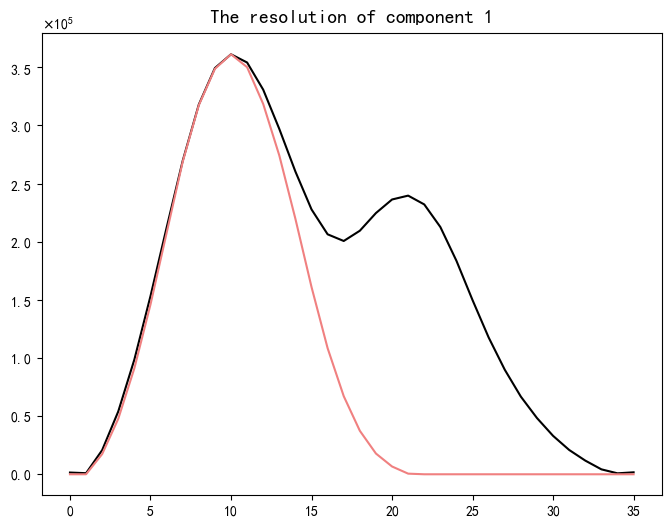

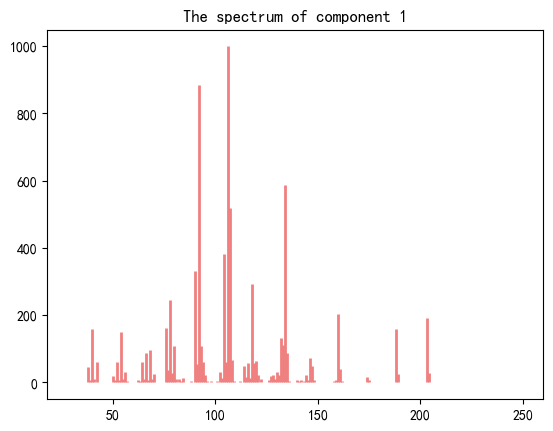

In [21]:
# Selective region
s = list(range(2, 15))
# co-elution region
o = list(range(15,20))
# Zero-concentration region
z = list(range(20,31))

# Full-rank resolution is performed on component 1.
c1, spec1, res_x = FRR(peak, s, o, z, 2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.sum(X, 1), color='black')
ax.plot(np.sum(res_x, 1), color='lightcoral')
ax.set_title('The resolution of component 1', fontsize=14, pad=8)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(formatter)
plt.show()

spectrum1 = spec1 / np.max(spec1) * 999
mz_ranges = np.arange(29,250)  # Only fragment intensities within the m/z range of 29 to 250 are displayed.
plt.vlines(mz_ranges, np.zeros((len(mz_ranges),)), spectrum1[29:250], color='lightcoral', linestyles='solid', linewidth=2)
plt.title('The spectrum of component 1')
plt.show()

**Strip the resolved compound information.**

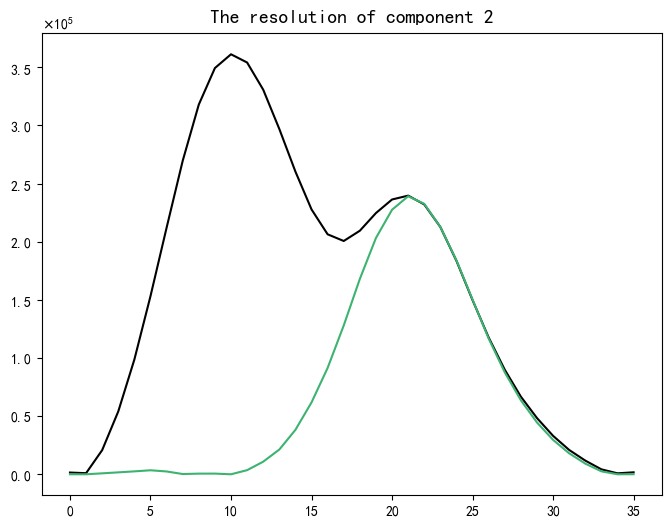

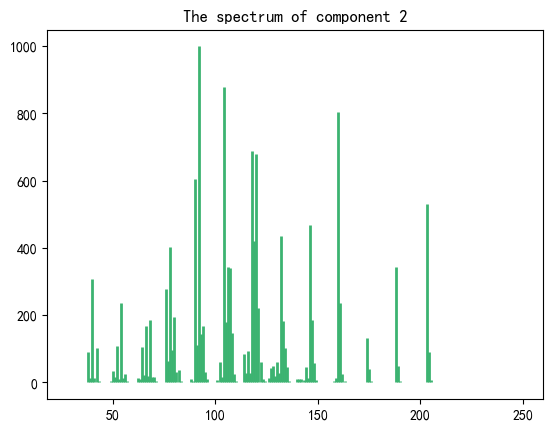

In [22]:
left_x = X - res_x
ind_s = np.argmax(np.abs(np.sum(left_x,1)))
spec2 = left_x[ind_s, :]
spectrum2 = spec2 / np.max(spec2) * 999
spectrum2 = spectrum2.reshape(1, 1000)

c2 = np.dot(np.dot(left_x, spectrum2.T), np.linalg.pinv(np.dot(spectrum2, spectrum2.T)))
re_left_x = np.dot(c2, spectrum2)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.sum(peak, 1), color='black')
ax.plot(np.sum(re_left_x, 1), color='mediumseagreen')
ax.set_title('The resolution of component 2', fontsize=14, pad=8)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(formatter)
plt.show()

mz_ranges = np.arange(29,250)  # Only fragment intensities within the m/z range of 29 to 250 are displayed.
plt.vlines(mz_ranges, np.zeros((len(mz_ranges),)), spectrum2.T[29:250], color='mediumseagreen', linestyles='solid', linewidth=2)
plt.title('The spectrum of component 2')
plt.show()

In [23]:
re_x = res_x+re_left_x
R2 = round(explained_variance_score(peak, re_x, multioutput='variance_weighted'), 3)
print(f"Explained variance score is {R2}")

Explained variance score is 0.997
